# 01 Data Overview（答辩展示：原始数据规模）

本 Notebook 用于向老师清晰展示：

- 原始数据来自哪里（目录）
- 原始数据有多少文件 / 多少行（数据规模）
- 覆盖多少城市 / 多长时间范围（覆盖度）
- 原始数据字段与缺失情况（数据质量）

> 建议按顺序运行，每个单元的输出都可截图。

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)

ROOT = Path(r"D:\Downloads\FYP CHINA\data")
RAW_DIR = ROOT / "cities"
TEMPO_DIR = ROOT / "tempo"

TEMPO_MASTER_DAILY = TEMPO_DIR / "master_daily.csv"
OLD_MASTER_DAILY = ROOT / "master_daily.csv"

print("RAW_DIR:", RAW_DIR)
print("TEMPO_MASTER_DAILY exists:", TEMPO_MASTER_DAILY.exists())
print("OLD_MASTER_DAILY exists:", OLD_MASTER_DAILY.exists())

RAW_DIR: D:\Downloads\FYP CHINA\data\cities
TEMPO_MASTER_DAILY exists: True
OLD_MASTER_DAILY exists: True


原始数据目录： D:\Downloads\FYP CHINA\data\cities
原始 CSV 文件数： 391
原始总记录行数（所有城市合计）： 17,335,839
原始数据总大小（GB）： 0.92


,file,rows,size_mb
351,长沙.csv,49695,2.64
107,安阳.csv,49691,2.68
93,大庆.csv,49690,2.62
358,阿克苏地区.csv,49689,3.09
350,长春.csv,49689,2.65
32,佛山.csv,49689,2.63
353,阜新.csv,49688,2.65
184,本溪.csv,49687,2.66
186,杭州.csv,49686,2.64
34,保定.csv,49685,2.66


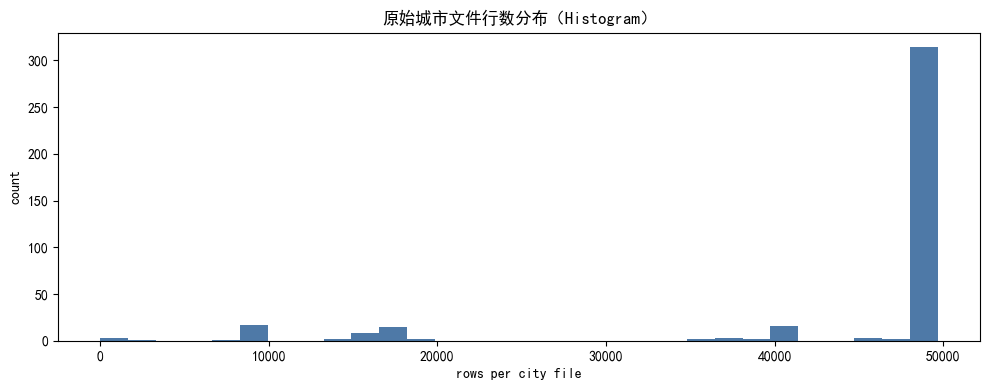

In [6]:
# 原始数据规模统计（推荐截图）
# 统计：文件数、总大小、总行数（快速按换行计数，不读入内存）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use a font that supports Chinese
plt.rcParams['axes.unicode_minus'] = False   # Correctly display minus signs
raw_files = sorted(RAW_DIR.glob("*.csv"))
if not raw_files:
    raise FileNotFoundError(f"未找到原始数据 CSV：{RAW_DIR}")


def count_lines_fast(path: Path, block_size: int = 1024 * 1024) -> int:
    # 二进制统计换行数量（包含 header），速度快且不受编码影响
    n = 0
    with path.open("rb") as f:
        while True:
            b = f.read(block_size)
            if not b:
                break
            n += b.count(b"\n")
    return n

sizes = []
rows = []
for fp in raw_files:
    sizes.append(fp.stat().st_size)
    # 行数 = 总行数 - 1（header）
    line_count = count_lines_fast(fp)
    rows.append(max(0, line_count - 1))

raw_total_files = len(raw_files)
raw_total_rows = int(np.sum(rows))
raw_total_gb = float(np.sum(sizes)) / (1024**3)

raw_stats_df = pd.DataFrame(
    {
        "file": [f.name for f in raw_files],
        "rows": rows,
        "size_mb": [round(s / (1024**2), 2) for s in sizes],
    }
).sort_values("rows", ascending=False)

print("原始数据目录：", RAW_DIR)
print("原始 CSV 文件数：", raw_total_files)
print("原始总记录行数（所有城市合计）：", f"{raw_total_rows:,}")
print("原始数据总大小（GB）：", round(raw_total_gb, 2))

# Top 10 最大文件（方便截图）
display(raw_stats_df.head(50))

plt.figure(figsize=(10, 4))
plt.hist(raw_stats_df["rows"], bins=30, color="#4e79a7")
plt.title("原始城市文件行数分布（Histogram）")
plt.xlabel("rows per city file")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [4]:
# 原始数据字段预览 + 缺失率（取一个样例城市文件，便于截图）
import pandas as pd

sample_file = raw_files[0]
# 尝试读取前 5000 行
try:
    sample_df = pd.read_csv(sample_file, nrows=5000, encoding="utf-8")
except Exception:
    sample_df = pd.read_csv(sample_file, nrows=5000, encoding="utf-8", errors="replace")

print("样例文件：", sample_file.name)
print("字段列表：", list(sample_df.columns))

display(sample_df.head(10))

# 缺失率概览
missing_rate = sample_df.isna().mean().sort_values(ascending=False)
display(pd.DataFrame({"column": missing_rate.index, "missing_rate": (missing_rate.values * 100).round(2)}))

样例文件： 七台河.csv
字段列表： ['date', 'hour', 'city', 'AQI', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5', 'SO2']


,date,hour,city,AQI,CO,NO2,O3,PM10,PM2.5,SO2
0,2020-01-01,0,七台河,63.0,0.8,44.0,29.0,58.0,45.0,17.0
1,2020-01-01,1,七台河,70.0,0.8,39.0,33.0,56.0,51.0,21.0
2,2020-01-01,2,七台河,74.0,0.8,47.0,27.0,63.0,54.0,18.0
3,2020-01-01,3,七台河,66.0,0.8,37.0,39.0,56.0,48.0,15.0
4,2020-01-01,4,七台河,60.0,0.8,34.0,36.0,58.0,43.0,17.0
5,2020-01-01,5,七台河,65.0,0.8,53.0,24.0,65.0,47.0,21.0
6,2020-01-01,6,七台河,81.0,0.8,48.0,33.0,72.0,60.0,21.0
7,2020-01-01,7,七台河,84.0,0.9,64.0,24.0,84.0,62.0,24.0
8,2020-01-01,8,七台河,85.0,1.0,68.0,22.0,103.0,63.0,27.0
9,2020-01-01,9,七台河,106.0,1.0,60.0,30.0,119.0,80.0,24.0


,column,missing_rate
0,CO,1.06
1,O3,0.90
2,PM10,0.86
3,NO2,0.54
4,SO2,0.52
5,PM2.5,0.46
6,date,0.00
7,hour,0.00
8,city,0.00
9,AQI,0.00


清洗后主表： D:\Downloads\FYP CHINA\data\tempo\master_daily.csv
清洗后 shape： (732503, 9)
清洗后城市数： 391
清洗后日期范围： 2020-01-01 ~ 2025-09-20


,year,rows
0,2020,133491
1,2021,134773
2,2022,124916
3,2023,124830
4,2024,125172
5,2025,89321


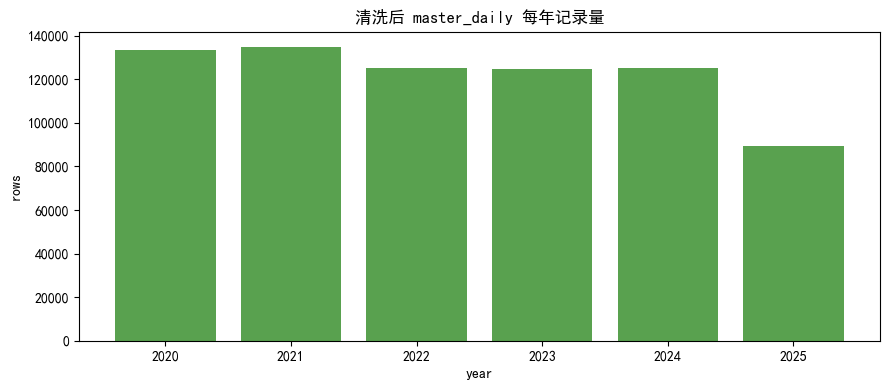

In [5]:
# 清洗前后数据规模对照（old vs tempo master_daily）
import pandas as pd
import numpy as np

# 清洗后（tempo）
if TEMPO_MASTER_DAILY.exists():
    clean_path = TEMPO_MASTER_DAILY
else:
    clean_path = OLD_MASTER_DAILY

clean_df = pd.read_csv(clean_path)
clean_df["date"] = pd.to_datetime(clean_df["date"], errors="coerce")
clean_df["year"] = clean_df["date"].dt.year
clean_per_year = clean_df.groupby("year", as_index=False).size().rename(columns={"size": "rows_after"})

# 清洗前（old master_daily，使用分块避免占用过大内存）
before_path = OLD_MASTER_DAILY
before_rows = 0
before_city_set = set()
before_min_date = None
before_max_date = None
before_year_counts = {}

if before_path.exists():
    for chunk in pd.read_csv(before_path, usecols=["date", "city"], chunksize=500_000):
        chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")
        before_rows += len(chunk)
        before_city_set.update(chunk["city"].dropna().astype(str).unique())

        cmin = chunk["date"].min()
        cmax = chunk["date"].max()
        if pd.notna(cmin):
            before_min_date = cmin if before_min_date is None else min(before_min_date, cmin)
        if pd.notna(cmax):
            before_max_date = cmax if before_max_date is None else max(before_max_date, cmax)

        yc = chunk["date"].dt.year.value_counts(dropna=True)
        for y, cnt in yc.items():
            before_year_counts[int(y)] = before_year_counts.get(int(y), 0) + int(cnt)

    before_per_year = pd.DataFrame(
        {"year": list(before_year_counts.keys()), "rows_before": list(before_year_counts.values())}
    ).sort_values("year")
else:
    before_per_year = pd.DataFrame(columns=["year", "rows_before"])

print("清洗前主表：", before_path)
print("清洗后主表：", clean_path)
print("-" * 60)
print("清洗前 shape：", (before_rows, "(分块统计)"))
print("清洗前城市数：", len(before_city_set))
print("清洗前日期范围：", before_min_date.date() if before_min_date is not None else None, "~", before_max_date.date() if before_max_date is not None else None)
print("-" * 60)
print("清洗后 shape：", clean_df.shape)
print("清洗后城市数：", clean_df["city"].nunique())
print("清洗后日期范围：", clean_df["date"].min().date(), "~", clean_df["date"].max().date())

compare_scale_df = pd.DataFrame([
    {
        "指标": "记录数",
        "清洗前": before_rows,
        "清洗后": int(len(clean_df)),
        "变化量": int(len(clean_df)) - before_rows,
    },
    {
        "指标": "城市数",
        "清洗前": len(before_city_set),
        "清洗后": int(clean_df["city"].nunique()),
        "变化量": int(clean_df["city"].nunique()) - len(before_city_set),
    },
])
display(compare_scale_df)

# 按年记录量对比（清洗前 vs 清洗后）
per_year_compare = before_per_year.merge(clean_per_year, on="year", how="outer").fillna(0).sort_values("year")
for col in ["rows_before", "rows_after"]:
    per_year_compare[col] = per_year_compare[col].astype(int)

display(per_year_compare)

x = np.arange(len(per_year_compare))
width = 0.4

plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, per_year_compare["rows_before"], width=width, label="清洗前", color="#4e79a7")
plt.bar(x + width / 2, per_year_compare["rows_after"], width=width, label="清洗后", color="#59a14f")
plt.xticks(x, per_year_compare["year"].astype(int).astype(str))
plt.title("清洗前后 master_daily 每年记录量对比")
plt.xlabel("year")
plt.ylabel("rows")
plt.legend()
plt.tight_layout()
plt.show()

## 答辩截图建议

1. **原始数据规模统计**（文件数、总行数、总大小、Top10 最大文件）
2. **样例原始文件字段与缺失率**（字段列表 + missing rate 表）
3. **清洗后数据规模对照**（master_daily shape、城市数、日期范围、每年记录量柱状图）

这三张截图就能清晰证明你的原始数据规模与后续数据处理工作量。